In [1]:
import nltk
from nltk.corpus import treebank
import statistics
import matplotlib.pyplot as plt
import numpy as np
import re

# Download and load corpus
nltk.download('treebank')
sentences = treebank.sents()
words = treebank.words()
tagged_words = treebank.tagged_words()

# Remove trace tokens and empty categories
TRACE_TOKEN_PATTERN = re.compile(r'^\*.*\*$|^\*$|^\*-?\d+$|^0$')
def is_valid_token(word, pos_tag=None):
    if pos_tag == '-NONE-':
        return False
    if TRACE_TOKEN_PATTERN.match(word):
        return False
    return True

# Cleaned sentences as strings
cleaned_sentences = []
for sentence in treebank.tagged_sents():
    cleaned_tokens = [word for word, pos in sentence if is_valid_token(word, pos)]
    if cleaned_tokens:
        cleaned_sentences.append(" ".join(cleaned_tokens))

# --- Remove outliers based on sentence length ---
sentence_lengths = [len(sentence.split()) for sentence in cleaned_sentences]
Q1 = np.percentile(sentence_lengths, 25)
Q3 = np.percentile(sentence_lengths, 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

filtered_cleaned_sentences = [
    sentence for sentence in cleaned_sentences
    if lower_bound <= len(sentence.split()) <= upper_bound
]

# Gather statistics on the filtered cleaned data
filtered_total_sentences = len(filtered_cleaned_sentences)
filtered_all_tokens = [token for sentence in filtered_cleaned_sentences for token in sentence.split()]
filtered_total_tokens = len(filtered_all_tokens)
filtered_unique_tokens = set(filtered_all_tokens)
filtered_total_unique_tokens = len(filtered_unique_tokens)

# Sentence length statistics
filtered_sentence_lengths = [len(sentence.split()) for sentence in filtered_cleaned_sentences]
if len(filtered_sentence_lengths) > 1:
    filtered_variance_sentence_length = round(statistics.pvariance(filtered_sentence_lengths), 3)
    filtered_std_dev_sentence_length = round(statistics.stdev(filtered_sentence_lengths), 3)
else:
    filtered_variance_sentence_length = 0
    filtered_std_dev_sentence_length = 0

# Average sentence length
filtered_average_sentence_length = round(filtered_total_tokens / filtered_total_sentences if filtered_total_sentences else 0, 3)

print(f"Original sentences: {len(cleaned_sentences)}")
print("\n--- Statistics for Filtered Cleaned Data ---")
print("Total number of sentences:", filtered_total_sentences)
print("Total number of words:", filtered_total_tokens)
print("Total number of unique words:", filtered_total_unique_tokens)
print("Average sentence length:", filtered_average_sentence_length)
print("Variance of sentence lengths:", filtered_variance_sentence_length)
print("Standard deviation of sentence lengths:", filtered_std_dev_sentence_length)

[nltk_data] Downloading package treebank to
[nltk_data]     /Users/larsheijnen/nltk_data...
[nltk_data]   Package treebank is already up-to-date!


Original sentences: 3914

--- Statistics for Filtered Cleaned Data ---
Total number of sentences: 3868
Total number of words: 90895
Total number of unique words: 11647
Average sentence length: 23.499
Variance of sentence lengths: 106.825
Standard deviation of sentence lengths: 10.337


In [2]:
from transformers import BertTokenizer, BertModel
import torch
import numpy as np

# Load BERT tokenizer and model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

# Function to create BERT embeddings for each sentence
def get_bert_embeddings(texts):
    embeddings = []
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model.to(device)
    model.eval()
    
    # Process in batches to avoid memory issues
    batch_size = 32
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i+batch_size]
            inputs = tokenizer(batch_texts, padding=True, truncation=True, return_tensors='pt').to(device)
            outputs = model(**inputs)
            
            # Get [CLS] token embedding for each sentence (first token)
            batch_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.extend(batch_embeddings)
    
    return np.array(embeddings)

# Generate BERT embeddings for preprocessed sentences without outliers
print("Generating BERT embeddings for filtered_cleaned_sentences (preprocessed, outliers removed)...")
X_sentence_features = get_bert_embeddings(filtered_cleaned_sentences)
print(f"Sentence BERT embeddings shape: {X_sentence_features.shape}")

Generating BERT embeddings for filtered_cleaned_sentences (preprocessed, outliers removed)...
Sentence BERT embeddings shape: (3868, 768)


In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    explained_variance_score,
    max_error,
    median_absolute_error
)
import numpy as np

# Target: sentence lengths
y = [len(sentence.split()) for sentence in filtered_cleaned_sentences]

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_sentence_features, y, test_size=0.2, random_state=42
)

# Train Linear Regression model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict on test set
y_pred = lr.predict(X_test)

# Evaluate the model with multiple metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
medae = median_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
explained_var = explained_variance_score(y_test, y_pred)
max_err = max_error(y_test, y_pred)

print(f"Test MSE: {mse:.3f}")
print(f"Test RMSE: {rmse:.3f}")
print(f"Test MAE: {mae:.3f}")
print(f"Test Median AE: {medae:.3f}")
print(f"Test Max Error: {max_err:.3f}")
print(f"Test R^2: {r2:.3f}")
print(f"Test Explained Variance: {explained_var:.3f}")

Test MSE: 18.289
Test RMSE: 4.277
Test MAE: 3.302
Test Median AE: 2.635
Test Max Error: 17.890
Test R^2: 0.837
Test Explained Variance: 0.838


In [4]:
from sklearn.model_selection import cross_val_score, KFold

# 5-fold cross-validation for Linear Regression
lr = LinearRegression()
kf = KFold(n_splits=5, shuffle=True, random_state=42)

mse_scores = -cross_val_score(lr, X_sentence_features, y, cv=kf, scoring='neg_mean_squared_error')
mae_scores = -cross_val_score(lr, X_sentence_features, y, cv=kf, scoring='neg_mean_absolute_error')
r2_scores = cross_val_score(lr, X_sentence_features, y, cv=kf, scoring='r2')
rmse_scores = np.sqrt(mse_scores)

print(f"Cross-validated MSE: {mse_scores.mean():.3f}")
print(f"Cross-validated RMSE: {rmse_scores.mean():.3f}")
print(f"Cross-validated MAE: {mae_scores.mean():.3f}")
print(f"Cross-validated R^2: {r2_scores.mean():.3f}")

Cross-validated MSE: 17.022
Cross-validated RMSE: 4.124
Cross-validated MAE: 3.208
Cross-validated R^2: 0.840


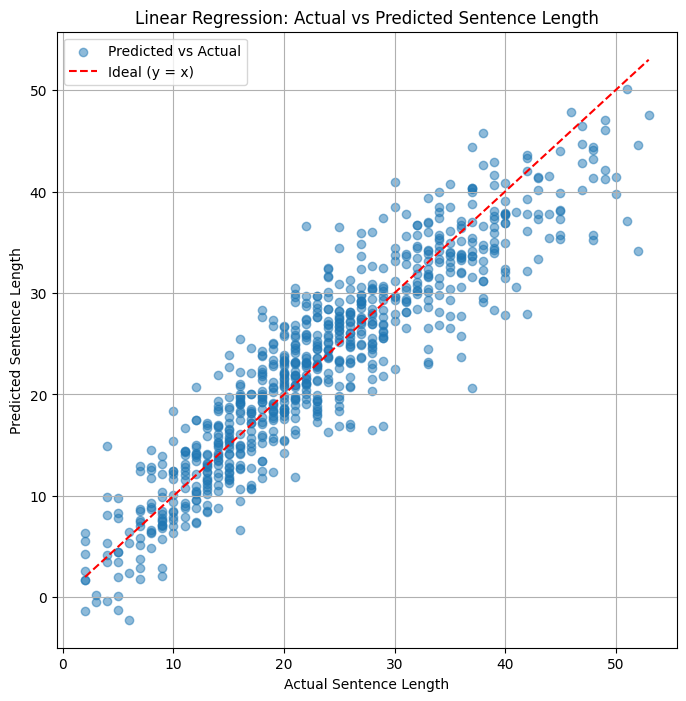

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5, label="Predicted vs Actual")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label="Ideal (y = x)")
plt.xlabel("Actual Sentence Length")
plt.ylabel("Predicted Sentence Length")
plt.title("Linear Regression: Actual vs Predicted Sentence Length")
plt.legend()
plt.grid(True)
plt.show()

In [6]:
import ipywidgets as widgets
from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split

            
X_train_sent, X_test_sentences, y_train_lengths, y_test_lengths, train_indices, test_indices = train_test_split(
    filtered_cleaned_sentences, y, list(range(len(filtered_cleaned_sentences))),
    test_size=0.2, random_state=42, shuffle=True, stratify=None
)

def show_sentence(idx):
    sent = X_test_sentences[idx]
    actual = y_test_lengths[idx]
    pred = y_pred[idx]
    display(Markdown(
        f"**Sentence:**<br>{sent}<br><br>"
        f"**Actual Length:** {actual}<br>"
        f"**Predicted Length:** {pred:.2f}"
    ))

slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(X_test_sentences)-1,
    step=1,
    description='Test idx:',
    continuous_update=False
)

widgets.interact(show_sentence, idx=slider)

interactive(children=(IntSlider(value=0, continuous_update=False, description='Test idx:', max=773), Output())…

<function __main__.show_sentence(idx)>

| Index | Tokens Sentence 10 | Tokens Sentence 18      | Tokens Sentence 370      | Tokens Sentence 545                                                                                   |
|-------|--------------------|------------------------|--------------------------|------------------------------------------------------------------------------------------------------|
| 1     | In                 | That                   | The                      | Campbell                                                                                            |
| 2     | 1973               | has                    | Transportation           | Soup                                                                                                |
| 3     | ,                  | been                   | Department               | ,                                                                                                   |
| 4     | Wells              | particularly           | ,                        | for                                                                                                 |
| 5     | Fargo              | true                   | responding               | one                                                                                                 |
| 6     | &                  | this                   | to                       | ,                                                                                                   |
| 7     | Co.                | year                   | pressure                 | is                                                                                                  |
| 8     | of                 | with                   | from                     | furious                                                                                             |
| 9     | San                | many                   | safety                   | its                                                                                                 |
| 10    | Francisco          | companies              | advocates                | Souper                                                                                              |
| 11    | launched           | raising                | ,                        | Combo                                                                                               |
| 12    | the                | their                  | took                     | microwave                                                                                           |
| 13    | Gold               | payouts                | further                  | product                                                                                             |
| 14    | Account            | more                   | steps                    | was                                                                                                 |
| 15    | ,                  | than                   | to                       | chastised                                                                                           |
| 16    | which              | 10                     | impose                   | in                                                                                                  |
| 17    | included           | %                      | on                       | the                                                                                                |
| 18    | free               | .                      | light                    | premiere                                                                                            |
| 19    | checking           |                        | trucks                   | ``                                                                                                  |
| 20    | ,                  |                        | and                      | In                                                                                                  |
| 21    | a                  |                        | vans                     | the                                                                                                |
| 22    | credit             |                        | the                      | Dumpster                                                                                            |
| 23    | card               |                        | safety                   | ''                                                                                                  |
| 24    | ,                  |                        | requirements             | column                                                                                              |
| 25    | safe-deposit       |                        | used                     | .                                                                                                   |
| 26    | box                |                        | for                      |                                                                                                     |
| 27    | and                |                        | automobiles              |                                                                                                     |
| 28    | travelers          |                        | .                        |                                                                                                     |
| 29    | checks             |                        |                          |                                                                                                     |
| 30    | for                |                        |                          |                                                                                                     |
| 31    | a                  |                        |                          |                                                                                                     |
| 32    | $                  |                        |                          |                                                                                                     |
| 33    | 3                  |                        |                          |                                                                                                     |
| 34    | monthly            |                        |                          |                                                                                                     |
| 35    | fee                |                        |                          |                                                                                                     |
| 36    | .                  |                        |                          |                                                                                                     |